In [1]:
import pandas as pd

# Load the clip labels created from Process_boxes_to_classifier_labels.ipynb
clip_labels = pd.read_csv('/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/OpenSoundScape/birds_embeddings_birdnet_padded_3s_condensed.csv')
# , index_col=[0,1,2]
# take only first 4 columns
clip_labels = clip_labels.iloc[:, :4]

# make calltype A and M the same = A
#clip_labels['calltype'] = clip_labels['calltype'].replace('M', 'A')
# make calltype N and chits the same = Chits
#clip_labels['calltype'] = clip_labels['calltype'].replace('N', 'Chits')
# make calltype L and C the same = C
#clip_labels['calltype'] = clip_labels['calltype'].replace('L', 'C')

# sort columns like file, start_time, end_time, call_type
clip_labels = clip_labels[['file', 'start_time', 'end_time', 'calltype']]
# make call_type one hot encoding (true or false)
clip_labels = pd.get_dummies(clip_labels, columns=['calltype'])
clip_labels


,file,start_time,end_time,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_G,calltype_J,calltype_K
0,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False
1,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
2,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
3,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
4,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5747,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
5748,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,False,False,False,False,True
5749,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
5750,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,True,False,False,False,False,False


In [2]:
classes = clip_labels.columns[3:].tolist()
classes

['calltype_A',
 'calltype_B',
 'calltype_C',
 'calltype_Check',
 'calltype_Cheer',
 'calltype_Chits',
 'calltype_D',
 'calltype_E',
 'calltype_G',
 'calltype_J',
 'calltype_K']

In [3]:
import os
import pandas as pd

# Path to YOLO dataset split files
split_dir = '/home/Shelby/blackbird_calls/Experiments/Detection_of_calls/Datasets/All_call_classes/Split_data_controlled/YOLO/dataset_split/'

# Read the split files and extract unique trial identifiers
def extract_trial_ids(txt_file):
    """Extract unique trial identifiers from YOLO split file"""
    with open(txt_file, 'r') as f:
        paths = [line.strip() for line in f]
    
    # Extract trial IDs from image filenames
    # Format: .../AZ02_Trial_1_trim_spec_00-05.png -> AZ02_Trial_1_trim
    trial_ids = set()
    for path in paths:
        filename = os.path.basename(path)
        # Remove _spec_XX-XX.png to get trial ID
        trial_id = filename.rsplit('_spec_', 1)[0]
        trial_ids.add(trial_id)
    
    return trial_ids

# Extract trial IDs for each split
test_trials = extract_trial_ids(os.path.join(split_dir, 'test.txt'))
val_trials = extract_trial_ids(os.path.join(split_dir, 'validate.txt'))
train_trials = extract_trial_ids(os.path.join(split_dir, 'train.txt'))

print(f"Test trials: {sorted(test_trials)}")
print(f"Validation trials: {sorted(val_trials)}")
print(f"Train trials ({len(train_trials)} total): {sorted(list(train_trials)[:5])}...")

# Create masks based on trial IDs in the audio file paths
def create_mask(clip_labels, trial_ids):
    """Create boolean mask for clips from specified trial IDs"""
    return clip_labels.reset_index()["file"].apply(
        lambda x: any(trial_id in x for trial_id in trial_ids)
    ).values

# Split the data
mask_test = create_mask(clip_labels, test_trials)
test_set = clip_labels[mask_test]

mask_val = create_mask(clip_labels, val_trials)
val_set = clip_labels[mask_val]

mask_train = create_mask(clip_labels, train_trials)
train_set = clip_labels[mask_train]

# Verify the split
print(f"\nSplit summary:")
print(f"Training set: {len(train_set)} clips")
print(f"Validation set: {len(val_set)} clips")
print(f"Test set: {len(test_set)} clips")
print(f"Total: {len(train_set) + len(val_set) + len(test_set)} clips")
print(f"Original total: {len(clip_labels)} clips")

Test trials: ['AZ02_Trial_1_trim', 'AZ16_Trial_1_trim', 'SL07_Trial_2_trim', 'SL23_Trial_1_trim', 'SL37_Trial_1_trim', 'SL37_Trial_2_trim', 'SL37_Trial_3_trim', 'SL40_Trial_1_trim', 'SL40_Trial_2_trim', 'SL40_Trial_3_trim', 'SL41_Trial_1_trim', 'SL41_Trial_2_trim', 'SL41_Trial_3_trim', 'SL43_Trial_3_trim', 'SL44_Trial_2_trim', 'SL52_Trial_2_trim']
Validation trials: ['AZ08_Trial_2_trim', 'AZ15_Trial_2_trim', 'EF01_Trial_1_trim', 'EF04_Trial_1_trim', 'SL01_Trial_2_trim', 'SL10_Trial_2_trim', 'SL12_Trial_3_trim', 'SL17b_Trial_3_trim', 'SL22_Trial_3_trim', 'SL23_Trial_2_trim', 'SL28_Trial_2_trim', 'SL35_Trial_1_trim', 'SL38_Trial_2_trim', 'SL49_Trial_1_trim', 'SL50_Trial_2_trim', 'SL56_Trial_1_trim']
Train trials (78 total): ['AZ02_Trial_2_trim', 'AZ13_Trial_3_trim', 'SL09_Trial_3_trim', 'SL52_Trial_1_trim', 'SL54_Trial_2_trim']...

Split summary:
Training set: 3660 clips
Validation set: 1135 clips
Test set: 938 clips
Total: 5733 clips
Original total: 5752 clips


In [4]:
# make index file and start time and end time
train_set = train_set.reset_index(drop=True)
val_set = val_set.reset_index(drop=True)
test_set = test_set.reset_index(drop=True)

# train_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
# val_set.set_index(['file', 'start_time', 'end_time'], inplace=True)
# test_set.set_index(['file', 'start_time', 'end_time'], inplace=True)

optional: upsampling or downsampling

In [5]:
train_set.head()

,file,start_time,end_time,calltype_A,calltype_B,calltype_C,calltype_Check,calltype_Cheer,calltype_Chits,calltype_D,calltype_E,calltype_G,calltype_J,calltype_K
0,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,False,False,True,False,False,False,False
1,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
2,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False
3,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,False,True,False,False,False,False,False,False
4,/home/Shelby/blackbird_calls/Experiments/Detec...,0.0,3.0,False,False,False,True,False,False,False,False,False,False,False


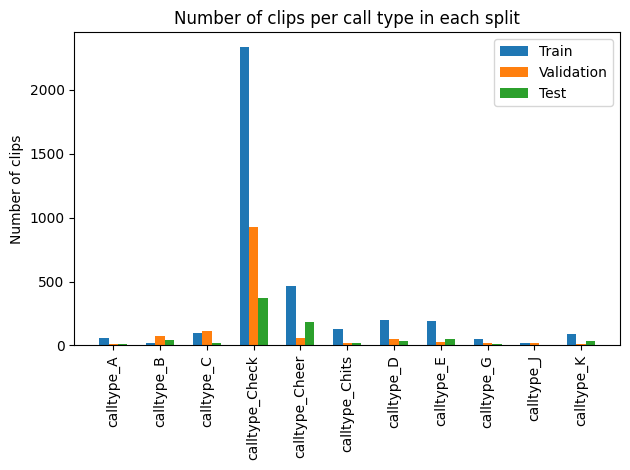

In [46]:
# bar plot number of calltype files in each split
import matplotlib.pyplot as plt
calltype_columns = [col for col in classes if col.startswith('calltype_')]
train_counts = train_set[calltype_columns].sum()
val_counts = val_set[calltype_columns].sum()
test_counts = test_set[calltype_columns].sum()
x = range(len(calltype_columns))
plt.bar(x, train_counts, width=0.2, label='Train')
plt.bar([i + 0.2 for i in x], val_counts, width=0.2, label='Validation')
plt.bar([i + 0.4 for i in x], test_counts, width=0.2, label='Test')
plt.xticks([i + 0.2 for i in x], calltype_columns, rotation=90)
plt.ylabel('Number of clips')
plt.title('Number of clips per call type in each split')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# print table of number of calltype files in each split
split_summary = pd.DataFrame({
    'Train': train_counts,
    'Validation': val_counts,
    'Test': test_counts
})
split_summary

,Train,Validation,Test
calltype_A,55,9,12
calltype_B,17,74,45
calltype_C,97,112,19
calltype_Check,2333,930,367
calltype_Cheer,464,59,184
calltype_Chits,125,18,19
calltype_D,195,47,34
calltype_E,192,29,51
calltype_G,47,18,12
calltype_J,19,16,4


In [40]:
set_copy = test_set.copy()
set_copy["trial"] = set_copy["file"].str.split("/").str[-1].str.split("_").str[0:3].str.join("_")

In [42]:
# Count call A occurrences per trial
a_counts_per_trial = set_copy[set_copy["calltype_K"] == 1].groupby("trial").size()
print("Number of call E occurrences per trial:")
print(a_counts_per_trial.sort_values(ascending=False))

Number of call E occurrences per trial:
trial
SL52_Trial_2    31
SL37_Trial_2     2
dtype: int64


In [44]:
# check calltypes and number of calltypes in SL12_Trial_2 in train
trial_name = "SL37_Trial_2"
set_copy[set_copy["trial"] == trial_name].iloc[:, 3:-1].sum()

calltype_A        0
calltype_B        0
calltype_C        0
calltype_Check    4
calltype_Cheer    0
calltype_Chits    1
calltype_D        0
calltype_E        0
calltype_G        0
calltype_J        0
calltype_K        2
dtype: int64

In [45]:
# change all values from SL12_Trial_2 from train_set to validation_set
mask_trial = set_copy["trial"] == trial_name
trial_data = test_set[mask_trial]
test_set = test_set[~mask_trial]
val_set = pd.concat([val_set, trial_data], ignore_index=True)

In [ ]:
# save splits to csv
train_set.to_csv('train_set_onehot.csv', index=False)
val_set.to_csv('val_set_onehot.csv', index=False)
test_set.to_csv('test_set_onehot.csv', index=False)